# Bài Tập Xây Dựng Mô Hình Decision Tree: Dự đoán giá xe (CarDekho)

## Giới Thiệu

Trong bài tập này, bạn sẽ xây dựng mô hình Decision Tree để dự đoán giá bán của xe ô tô cũ dựa trên một số đặc điểm kỹ thuật và thông tin mô tả xe trong bộ dữ liệu **cardekho_data.csv**. Bạn sẽ thực hành các bước tiền xử lý dữ liệu, xây dựng mô hình, đánh giá và cải thiện mô hình.


## Bước 1: Nhập các thư viện và bộ dữ liệu

Hãy nhập các thư viện cần thiết cho bài tập này. Bạn sẽ cần sử dụng `pandas` và `numpy` để xử lý dữ liệu, `DecisionTreeRegressor` và các hàm từ `sklearn` để xây dựng mô hình, cũng như `matplotlib` hoặc `seaborn` để trực quan hóa.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from datetime import datetime
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


carDf = pd.read_csv('cardekho_data - cardekho_data.csv')
carDf
carDf.info()

print('Fuel_Type', carDf['Fuel_Type'].unique())
print('Seller_Type', carDf['Seller_Type'].unique())
print('Transmission', carDf['Transmission'].unique())
print('Car_Name', carDf['Car_Name'].unique())
carDf



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
Fuel_Type ['Petrol' 'Diesel' 'CNG']
Seller_Type ['Dealer' 'Individual']
Transmission ['Manual' 'Automatic']
Car_Name ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' '

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [15]:
carFeatureDf = carDf[['Year', 'Selling_Price', 'Present_Price','Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']]
carFeatureDf

carFeatureEncoderDf = pd.get_dummies(carFeatureDf, drop_first=True, dtype=int)
carFeatureEncoderDf

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,1,0,0,1
297,2015,4.00,5.90,60000,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,1,0,1
299,2017,11.50,12.50,9000,0,1,0,0,1


### Nhập các thư viện cần thiết

In [16]:
# Thư viện xử lý dữ liệu

### CODE CỦA BẠN ###

# Thư viện xây dựng và đánh giá mô hình Decision Tree

### CODE CỦA BẠN ###

# Thư viện trực quan hóa dữ liệu

### CODE CỦA BẠN ###


### Nhập bộ dữ liệu

In [17]:
# Đọc bộ dữ liệu từ file CSV
# Sử dụng tên DataFrame là df_original

### CODE CỦA BẠN ###

# Ví dụ (bạn có thể tham khảo để viết code của mình, không cần chạy):
# df_original = pd.read_csv('cardekho_data.csv')


### Kiểm tra 10 dòng đầu tiên của bộ dữ liệu

In [18]:
# Hiển thị 10 dòng đầu tiên của DataFrame

### CODE CỦA BẠN ###


## Bước 2: Khám phá, làm sạch và chuẩn bị dữ liệu cho mô hình


### Khám phá bộ dữ liệu

- Kiểm tra loại dữ liệu của từng cột để biết được cột nào là dạng số, cột nào là dạng phân loại.
- Kiểm tra số dòng và số cột của bộ dữ liệu.
- In ra mô tả thống kê (mean, min, max, …) cho các biến số.


In [19]:
# Kiểm tra kiểu dữ liệu, kích thước và mô tả thống kê của bộ dữ liệu

### CODE CỦA BẠN ###


### Kiểm tra các nhóm của các biến phân loại

Hãy in ra danh sách các giá trị duy nhất của các trường `Fuel_Type`, `Seller_Type`, `Transmission` và `Owner` để hiểu rõ các nhóm dữ liệu này.


In [20]:
# In các giá trị duy nhất của từng biến phân loại

### CODE CỦA BẠN ###


### Kiểm tra biến mục tiêu

Biến mục tiêu trong bài toán này là `Selling_Price` (giá bán). Hãy kiểm tra phân bố của biến này bằng cách hiển thị các thống kê mô tả và biểu đồ phân bố.


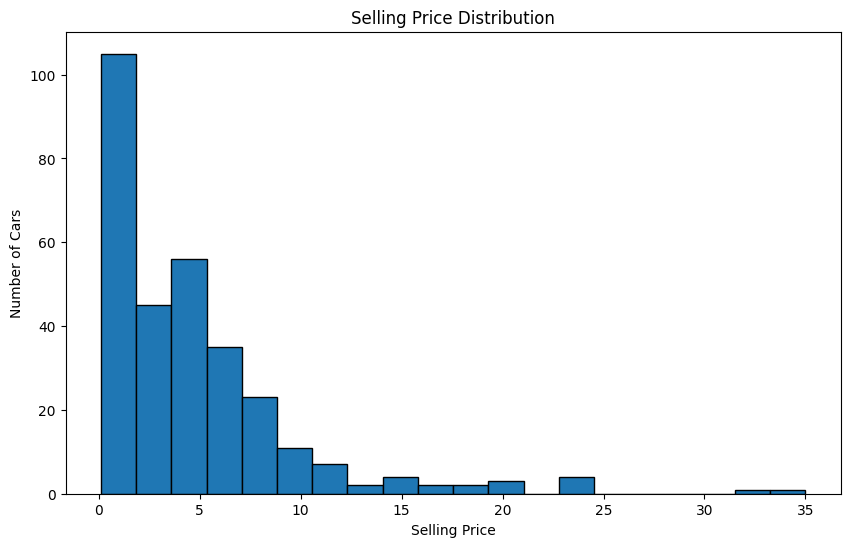

In [21]:
# Kiểm tra phân bố của biến Selling_Price
plt.figure(figsize=(10,6))
plt.hist(carFeatureEncoderDf['Selling_Price'], bins=20, edgecolor='black')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

### CODE CỦA BẠN ###


**Câu hỏi:** Bạn nhận xét gì về phân bố của giá bán?

Giá bán phân bố lệch trái, giá bán tập trung nhiều nhất ở vùng giá 1,5k trở lại

### Kiểm tra các dữ liệu trống

Cây quyết định không thể hoạt động tốt với các giá trị bị thiếu. Hãy đếm số lượng giá trị trống ở mỗi cột.


In [22]:
# Kiểm tra số lượng giá trị trống trong từng cột

### CODE CỦA BẠN ###

carFeatureEncoderDf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    301 non-null    int64  
 1   Selling_Price           301 non-null    float64
 2   Present_Price           301 non-null    float64
 3   Kms_Driven              301 non-null    int64  
 4   Owner                   301 non-null    int64  
 5   Fuel_Type_Diesel        301 non-null    int64  
 6   Fuel_Type_Petrol        301 non-null    int64  
 7   Seller_Type_Individual  301 non-null    int64  
 8   Transmission_Manual     301 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.3 KB


**Câu hỏi:** Tại sao chúng ta cần kiểm tra và xử lý dữ liệu trống trong bộ dữ liệu?

Decision Tree sẽ hoạt động không tốt khi có dữ liệu bị trống

### Tạo biến tuổi xe và loại bỏ cột `Year`

Chúng ta tạo một biến mới `Age` tính bằng `2026 - Year` để đo tuổi của xe. Sau khi tạo biến này, hãy loại bỏ cột `Year` cũ khỏi DataFrame.


In [23]:
# Tạo biến Age và loại bỏ cột Year

### CODE CỦA BẠN ###
carFeatureEncoderDf['Year'] = carFeatureEncoderDf['Year'].astype(int)
carFeatureEncoderDf
carFeatureEncoderDf['Age'] = carFeatureEncoderDf['Year'].apply(lambda year: datetime.now().year - year)


In [24]:
carFeatureEncoderDf = carFeatureEncoderDf.drop(columns=['Year'])

In [25]:
carFeatureEncoderDf
carFeatureEncoderDf.info()
carFeatureEncoderDf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Selling_Price           301 non-null    float64
 1   Present_Price           301 non-null    float64
 2   Kms_Driven              301 non-null    int64  
 3   Owner                   301 non-null    int64  
 4   Fuel_Type_Diesel        301 non-null    int64  
 5   Fuel_Type_Petrol        301 non-null    int64  
 6   Seller_Type_Individual  301 non-null    int64  
 7   Transmission_Manual     301 non-null    int64  
 8   Age                     301 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.3 KB


,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Age
0,3.35,5.59,27000,0,0,1,0,1,12
1,4.75,9.54,43000,0,1,0,0,1,13
2,7.25,9.85,6900,0,0,1,0,1,9
3,2.85,4.15,5200,0,0,1,0,1,15
4,4.60,6.87,42450,0,1,0,0,1,12
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,1,0,0,1,10
297,4.00,5.90,60000,0,0,1,0,1,11
298,3.35,11.00,87934,0,0,1,0,1,17
299,11.50,12.50,9000,0,1,0,0,1,9


### Xử lý cột `Car_Name`

Cột `Car_Name` có rất nhiều giá trị khác nhau (hàng chục tên xe). Việc mã hóa tất cả các tên xe có thể gây ra dữ liệu quá thưa thớt hoặc không cần thiết. Hãy thử loại bỏ cột này khỏi DataFrame để đơn giản hóa mô hình.


In [26]:
# Loại bỏ cột Car_Name khỏi DataFrame

### CODE CỦA BẠN ###


### Kiểm tra lại số dòng và cột của dữ liệu

In [27]:
# Kiểm tra kích thước của DataFrame sau khi xử lý cột

### CODE CỦA BẠN ###

print(len(carFeatureEncoderDf))


301


### Tạo biến giả (one-hot) cho các biến phân loại

Các biến phân loại `Fuel_Type`, `Seller_Type`, `Transmission` và `Owner` cần được chuyển thành dạng số bằng kỹ thuật one-hot encoding. Hãy tạo các biến giả cho những cột này.


In [28]:
# Tạo biến giả bằng phương thức get_dummies

### CODE CỦA BẠN ###


### Kiểm tra lại kiểu dữ liệu của từng cột

Sau khi mã hóa, hãy kiểm tra lại kiểu dữ liệu để đảm bảo tất cả các biến đều ở dạng số.


In [29]:
# Kiểm tra kiểu dữ liệu sau khi one-hot encoding

### CODE CỦA BẠN ###


### Tạo bộ dữ liệu train và bộ dữ liệu test

Hãy chia dữ liệu thành tập train và tập test. Biến mục tiêu là `Selling_Price`; các biến còn lại là biến đầu vào.


In [30]:
# Tách biến đầu vào (X) và biến mục tiêu (y), sau đó chia train/test

### CODE CỦA BẠN ###

y = carFeatureEncoderDf['Selling_Price']
y

x = carFeatureEncoderDf.drop(columns=['Selling_Price'])
x

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

carFeatureEncoderDf


,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Age
0,3.35,5.59,27000,0,0,1,0,1,12
1,4.75,9.54,43000,0,1,0,0,1,13
2,7.25,9.85,6900,0,0,1,0,1,9
3,2.85,4.15,5200,0,0,1,0,1,15
4,4.60,6.87,42450,0,1,0,0,1,12
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,1,0,0,1,10
297,4.00,5.90,60000,0,0,1,0,1,11
298,3.35,11.00,87934,0,0,1,0,1,17
299,11.50,12.50,9000,0,1,0,0,1,9


## Bước 3: Xây dựng mô hình Decision Tree

### Đưa dữ liệu train vào mô hình

Tạo một `DecisionTreeRegressor` với `random_state = 8` để những người khác có thể tái tạo kết quả của bạn. Sau đó, huấn luyện mô hình trên tập train và dự đoán trên tập test.


In [31]:
# Tạo và huấn luyện mô hình DecisionTreeRegressor

### CODE CỦA BẠN ###

carSellingTree = DecisionTreeRegressor(random_state=8)
carSellingTree.fit(x_train, y_train)
# Dự đoán và đánh giá mô hình Decision Tree
y_pred_tree = carSellingTree.predict(x_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_tree})
results.head(10)



,Actual,Predicted
177,0.35,0.50
289,10.11,11.25
228,4.95,5.95
198,0.15,0.20
60,6.95,4.50
9,7.45,7.45
118,1.10,1.11
154,0.50,0.75
164,0.45,0.50
33,6.00,4.75


**Câu hỏi:** Ưu điểm của mô hình Decision Tree đối với bài toán dự đoán giá xe so với các mô hình tuyến tính là gì?

[Hãy viết câu trả lời của bạn tại đây. Hãy nhấn hai lần vào ô này để chỉnh sửa]

## Bước 4: Kết quả và đánh giá mô hình

Hãy tính toán và in ra các chỉ số đánh giá cho mô hình bao gồm:

- **MSE** (Mean Squared Error)
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R² Score** (Hệ số xác định)

Sử dụng tập test để tính các chỉ số này.


In [32]:
# Tính toán các chỉ số đánh giá mô hình

### CODE CỦA BẠN ###
mse = mean_squared_error(y_test, y_pred_tree)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Performance:")
print("Mean Squared Error (MSE):", round(mse,4))
print("Root Mean Squared Error (RMSE):", round(rmse,4))
print("Mean Absolute Error (MAE):", round(mae,4))
print("R-squared (R2):", round(r2,4))

Decision Tree Regressor Performance:
Mean Squared Error (MSE): 7.1446
Root Mean Squared Error (RMSE): 2.6729
Mean Absolute Error (MAE): 1.0151
R-squared (R2): 0.7927


# Tính toán các chỉ số đánh giá
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

**Câu hỏi:** Trong các chỉ số trên, chỉ số nào theo bạn phản ánh tốt nhất chất lượng mô hình? Giải thích.

[Hãy viết câu trả lời của bạn tại đây. Hãy nhấn hai lần vào ô này để chỉnh sửa]

### Trực quan hóa cây quyết định

Sử dụng hàm `plot_tree` để trực quan hóa mô hình cây quyết định mà bạn đã xây dựng. Bạn có thể giới hạn độ sâu hiển thị (chẳng hạn `max_depth=3`) để biểu đồ dễ quan sát hơn.


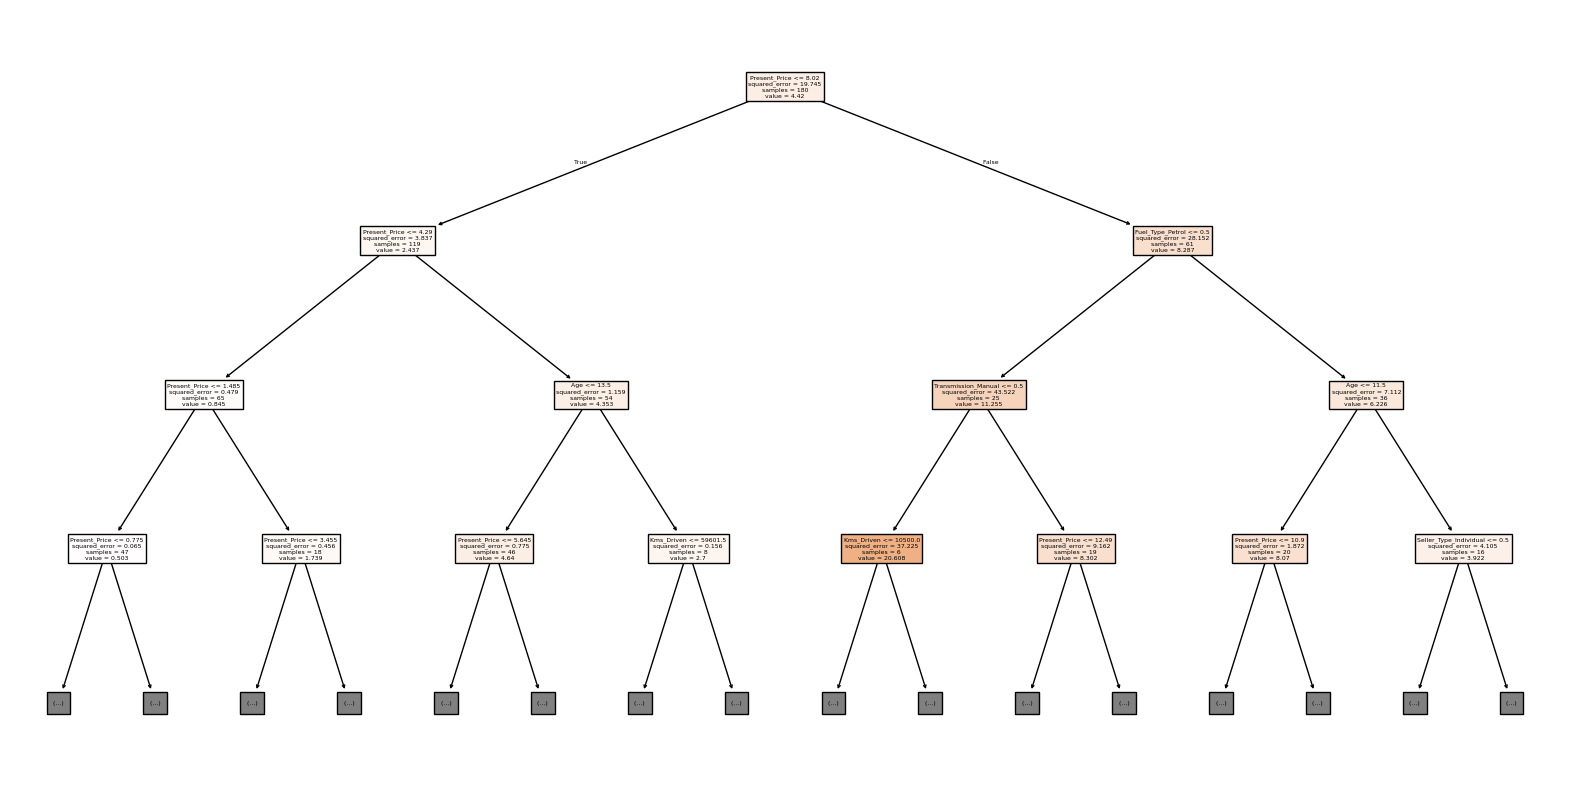

In [33]:
# Trực quan hóa cây quyết định

### CODE CỦA BẠN ###

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(carSellingTree, filled=True, feature_names=x.columns, max_depth=3)
plt.show()  


## Bước 5: Tính toán độ quan trọng của các biến độc lập

Mô hình `DecisionTreeRegressor` có thuộc tính `feature_importances_` cho biết mức độ quan trọng của từng biến đầu vào. Hãy sử dụng thuộc tính này để tạo DataFrame mô tả tầm quan trọng của các biến và trực quan hóa bằng biểu đồ cột.


In [34]:
# Tính và hiển thị độ quan trọng của các biến

### CODE CỦA BẠN ###
carSellingImportantFeatures = carSellingTree.feature_importances_
carSellingImportantFeatures
carSellingImportantFeatures = pd.Series(carSellingImportantFeatures, index=x.columns).sort_values(ascending=False)
carSellingImportantFeatures

Present_Price             0.550305
Transmission_Manual       0.194614
Fuel_Type_Petrol          0.104995
Age                       0.070107
Kms_Driven                0.066126
Seller_Type_Individual    0.013617
Fuel_Type_Diesel          0.000212
Owner                     0.000023
dtype: float64

**Câu hỏi:** Theo bạn, biến nào có ảnh hưởng lớn nhất đến giá xe? Vì sao?

[Hãy viết câu trả lời của bạn tại đây. Hãy nhấn hai lần vào ô này để chỉnh sửa]

## Bước 6: Tune các hyperparameter

Để cải thiện mô hình, bạn có thể thử nhiều giá trị cho các tham số quan trọng của cây quyết định, chẳng hạn như `max_depth` và `min_samples_leaf`. Hãy sử dụng `GridSearchCV` với kiểm chứng chéo k-fold (ví dụ `cv=5`) để tìm ra cặp giá trị tối ưu cho các tham số này. Đặt `random_state=8`.


In [35]:
# Thiết lập lưới tham số và thực hiện GridSearchCV

### CODE CỦA BẠN ###
from sklearn.model_selection import GridSearchCV
# hyper_params = {
#     'max_depth': [3, 5, 7, 10, 15, None],
#     'min_samples_split': [2, 5, 10, 20, 45],
#     'min_samples_leaf': [2, 5, 10, 20, 45]
#     }

# scoring = {'accuracy' : 'accuracy', 'f1' : 'f1', 'recall' : 'recall', 'precision' : 'precision'}

# grid_search = GridSearchCV(estimator=carSellingTree, param_grid=hyper_params, scoring=scoring, refit='accuracy', cv=5)
# grid_search.fit(x_train, y_train)

param_grid = {
    'max_depth': [None, 2, 3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

# Thiết lập GridSearchCV
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=8), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_dt.fit(x_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...andom_state=8)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 2, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

### Xác định các chỉ số đánh giá cho mô hình tối ưu

Sau khi tìm được mô hình với tham số tối ưu, hãy in ra giá trị của các tham số đó và tính toán lại MSE, RMSE, MAE và R² trên tập test.


In [36]:
# Hiển thị tham số tối ưu và đánh giá mô hình mới

### CODE CỦA BẠN ###

best_tree = grid_dt.best_estimator_
tree_pred = best_tree.predict(x_test)

mse = mean_squared_error(y_test, tree_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, tree_pred)
r2 = r2_score(y_test, tree_pred)


print("Decision Tree Regressor Performance:")
print("Mean Squared Error (MSE):",  round(mse,4))
print("Root Mean Squared Error (RMSE):", round(rmse,4))
print("Mean Absolute Error (MAE):", round(mae,4))
print("R-squared (R2):", round(r2,4))

Decision Tree Regressor Performance:
Mean Squared Error (MSE): 7.6539
Root Mean Squared Error (RMSE): 2.7666
Mean Absolute Error (MAE): 1.0618
R-squared (R2): 0.7779


Best parameters: {'max_depth': 7, 'min_samples_leaf': 1}
MSE: 2.7897
RMSE: 1.6702
MAE: 0.8826
R^2: 0.8957

Decision Tree Regressor Performance:
Mean Squared Error (MSE): 7.1446
Root Mean Squared Error (RMSE): 2.6729
Mean Absolute Error (MAE): 1.0151
R-squared (R2): 0.7927


**Câu hỏi:** Việc tune hyperparameter có giúp cải thiện mô hình đáng kể không? Vì sao?

[Hãy viết câu trả lời của bạn tại đây. Hãy nhấn hai lần vào ô này để chỉnh sửa]